#Student Depression 2025 Dataset - Exploratory Data Analyses

This dataset examines the connection between mental health and various demographic, academic, and lifestyle factors.

##Data Dictionary

**Gender:** 1 = male, 2 = female

**Academic Pressure:** 1 (low) to 5 (high)

**Study Satisfaction:** 1 (low) to 5 (high)

**Sleep Duration:**   
1 = Less than 5 hours,  
2 = 5-6 hours,   
3 =  7-8 hours,  
4 = More than 8 hours.

**Financial Stress:** 1 (low) to 5 (high)

**Dietary Habits:** Unhealthy = 0, Moderate = 1, Healthy = 2

Have you ever had suicidal thoughts?: Yes = 1, No = 2

In [1]:
# Import necessary libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/taicichin/Student-Depression-2025/refs/heads/main/Depression%20Student%20Dataset.csv')

# Display the first few rows of the dataset
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


#Data Cleaning and Preprocessing

In this stage, the dataset was analysed if there were any null cells using info() and isnull() functions, and the statistical summary of the numerical columns was obtained using the describe() function, including mean, standard deviation, and quartiles.

Columns names were changed to facilitate coding.

Dictinaries were created and the function map() used to convert strings into numerical value in order to use a correlation in the data visualization stage.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [3]:
df.isnull().sum()

,0
Gender,0
Age,0
Academic Pressure,0
Study Satisfaction,0
Sleep Duration,0
Dietary Habits,0
Have you ever had suicidal thoughts ?,0
Study Hours,0
Financial Stress,0
Family History of Mental Illness,0


In [4]:
df.describe()

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [9]:
# Rename columns with long names

df.rename(columns={'Have you ever had suicidal thoughts ?' : 'Suicidal_Thoughts'}, inplace = True)
df.rename(columns={'Family History of Mental Illness' : 'Family History'}, inplace = True)

In [6]:
# Convert Sleep Duration in numerical values

dic = {'Less than 5 hours' : 1,'5-6 hours': 2, '7-8 hours' : 3, 'More than 8 hours': 4}
df['Sleep Duration'] = df['Sleep Duration'].map(dic)

In [13]:
# Convert Depression, Suicidal Thoughts and Family History in numerical values

dic_2 = {'Yes' : 1, 'No':0}
df['Depression'] = df['Depression'].map(dic_2)
df['Suicidal_Thoughts'] = df['Suicidal_Thoughts'].map(dic_2)
df['Family History'] = df['Family History'].map(dic_2)

In [14]:
# Convert Gender in numerical values

dic_3 = {'Male':1, 'Female':2}
df['Gender'] = df['Gender'].map(dic_3)

In [16]:
# Convert Dietary Habits in numerical values

dic_4 = {'Unhealthy':0, 'Moderate':1, 'Healthy':2}
df['Dietary Habits'] = df['Dietary Habits'].map(dic_4)

##Analysis

General information about the dataset:
Depression rate of 50%, the dataset was well distributed among both gender, the age range was from 18 to 34 with no significant peaks.

To identify relationships between variables, a heatmap was plotted, where the following variables showed potential for further analysis: Academic Pressure, Suicidal Thoughts, Financial Stress, Study Satisfaction, Dietary habits and age.
Afterwards, another correlation was plotted to analyse whether academic pressure and sleep duration had a combined effect on depresion rates. Finally, t-tests were run to validate the findings.


In [19]:
# Rate of depression

df['Depression'].mean()

np.float64(0.50199203187251)

In [21]:
# Gender distribuition

df['Gender'].value_counts()

,count
Gender,
1,267
2,235


<Axes: xlabel='Age', ylabel='count'>

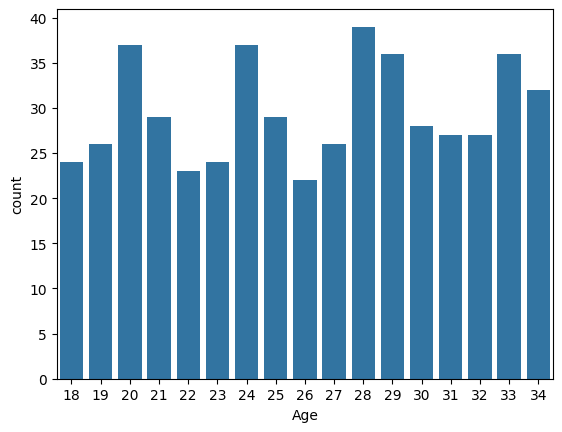

In [23]:
# Age distribuition

sns.countplot(data=df, x='Age')

<Axes: >

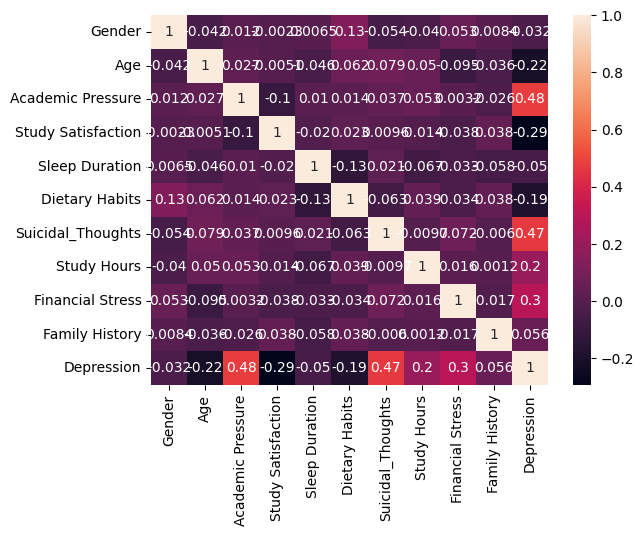

In [25]:
# The following heatmap shows the correlation between all numerical variables.

correlacao = df.corr(numeric_only=True)

sns.heatmap(correlacao, annot=True)

<Axes: xlabel='Academic Pressure', ylabel='Depression'>

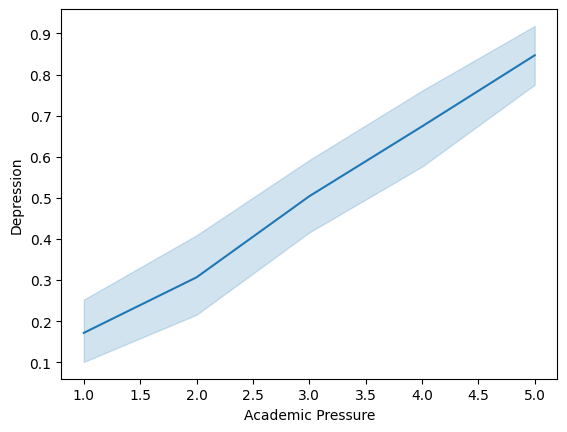

In [27]:
# Relationship between academic pressure and depression

sns.lineplot(data=df, x='Academic Pressure', y='Depression')

<Axes: xlabel='Suicidal_Thoughts', ylabel='Depression'>

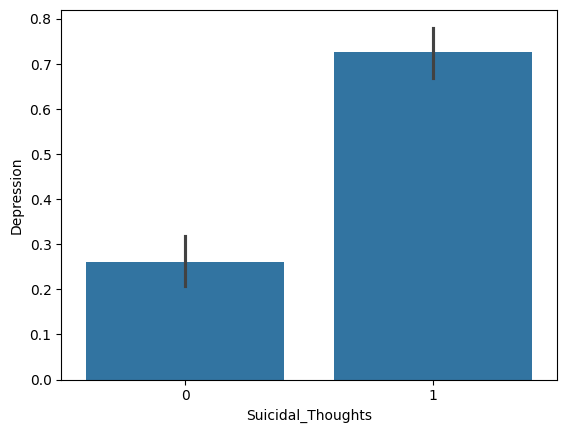

In [29]:
# Relationship between suicidal thoughts and depression

sns.barplot(data=df, x='Suicidal_Thoughts', y='Depression')

<Axes: xlabel='Financial Stress', ylabel='Depression'>

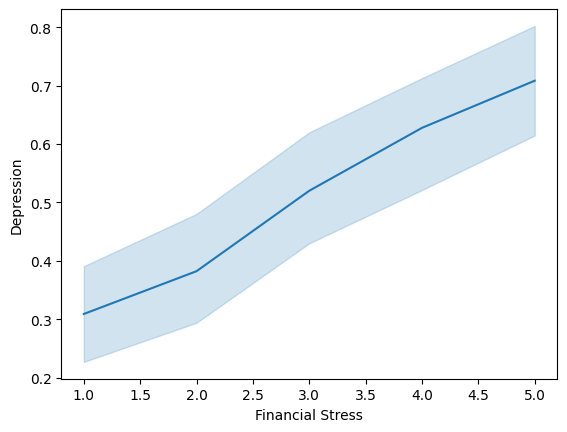

In [31]:
# Relationship between financial stress and depression

sns.lineplot(data=df, x='Financial Stress', y='Depression')

<Axes: xlabel='Study Satisfaction', ylabel='Depression'>

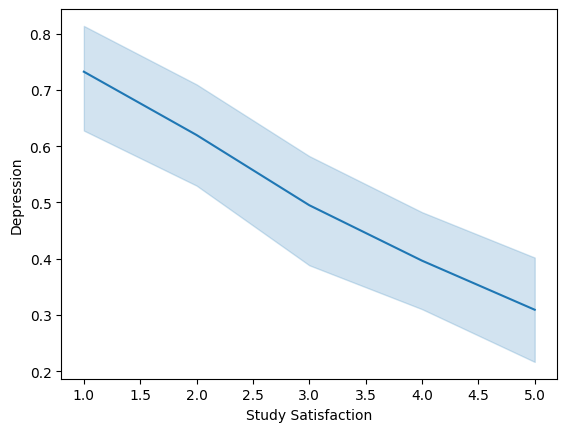

In [33]:
# Relationship between study satisfaction and depression

sns.lineplot(data=df, x='Study Satisfaction', y='Depression')

<Axes: xlabel='Dietary Habits', ylabel='Depression'>

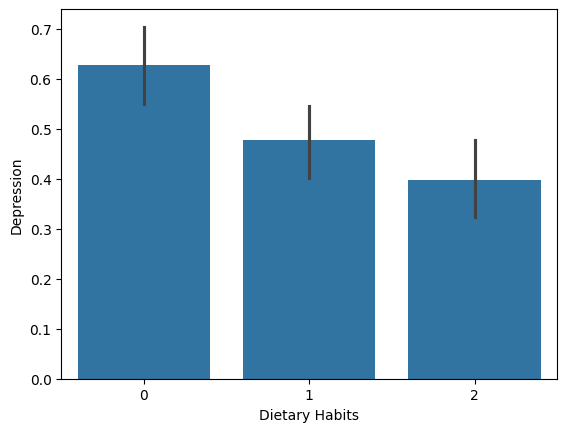

In [35]:
# Relationship between dietary hibits and depression

sns.barplot(data=df, x='Dietary Habits', y='Depression')

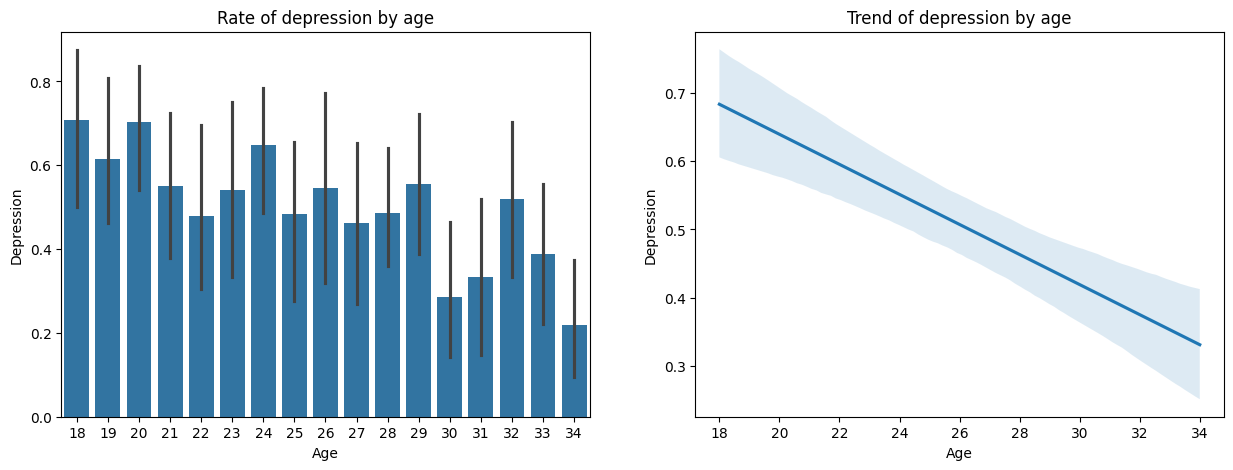

In [37]:
# Relationship between age and depression

fig, axs = plt.subplots(1, 2, figsize=(15,5))
#axs: subplots(linhas, colunas)

sns.barplot(data=df, x='Age', y='Depression', ax=axs[0])
axs[0].set_title('Rate of depression by age')

sns.regplot(data=df, x='Age', y='Depression', scatter=False)
axs[1].set_title('Trend of depression by age')

plt.show()

<Axes: xlabel='Sleep Duration', ylabel='Academic Pressure'>

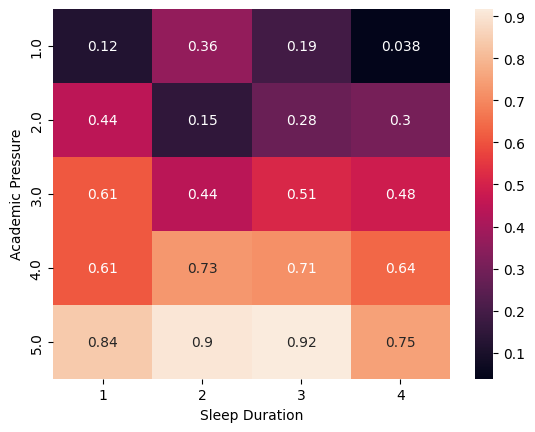

In [45]:
# Correlation between Academic Pressure, Sleep Duration and depression

tabela = df.groupby(['Academic Pressure', 'Sleep Duration'])['Depression'].mean().unstack()
sns.heatmap(tabela, annot=True)

# dormir mais ajuda, mas não compensa pressão acadêmica extrema.

In [47]:
grupo_alta = df[df['Academic Pressure'] == 5]['Depression']
grupo_baixa = df[df['Academic Pressure'] == 1]['Depression']

stats.ttest_ind(grupo_alta, grupo_baixa)

TtestResult(statistic=np.float64(12.78545610756119), pvalue=np.float64(1.3923802985932104e-27), df=np.float64(195.0))

In [46]:
grupo_alto = df[df['Financial Stress'] == 5]['Depression']
grupo_baixo = df[df['Financial Stress'] == 1]['Depression']

stats.ttest_ind(grupo_alto, grupo_baixo)

TtestResult(statistic=np.float64(6.202755007075421), pvalue=np.float64(3.03526141802741e-09), df=np.float64(204.0))

In [48]:
low_satisfaction = df[df['Study Satisfaction'] == 1]['Depression']
high_satisfaction = df[df['Study Satisfaction'] == 5]['Depression']

stats.ttest_ind(low_satisfaction, high_satisfaction)

TtestResult(statistic=np.float64(6.272677461522639), pvalue=np.float64(2.541545250151285e-09), df=np.float64(181.0))

Depressed Student Profile

Depressed students are more likely to have unhealthy dietary habits, lower study satisfaction, higher financial stress and higher academic pressure."